In [ ]:
from datetime import datetime, timedelta
from collections import deque, defaultdict, Counter
import matplotlib.pyplot as plt

from aqi_pkg.db import get_session
from aqi_pkg.filters import *
from aqi_pkg.ml.clustering import *

import polars as pl
import numpy as np

from geopy.distance import geodesic
import matplotlib.pyplot as plt

In [3]:
def get_all_data() -> pl.DataFrame:
    filter = Filter()
    loader = DataLoader(filter)

    data = loader.get_df()
    return data

In [4]:
start_time = datetime.now()
session = get_session()
plt.style.use("tableau-colorblind10")
try:
    df = get_all_data()
finally:
    session.close()
    print("Session closed.")
end_time = datetime.now()
print(f"Execution time: {end_time - start_time}")

Session closed.
Execution time: 0:00:12.501209


In [5]:
df.head()

scrape_id,lat,lon,locationId,city,state,country,last_updated,AQI_IN,AQI_US,CO_PPB,NO2_PPB,O3_PPB,SO2_PPB,PM1_UGM3,PM2_5_UGM3,PM10_UGM3,H_PERCENT,T_C,TVOC_PPM,Noise_DB
i64,f64,f64,str,str,str,str,datetime[μs],i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
6537854,28.4501,76.9882,"""8856A6EF1188""","""Gurgaon""","""Haryana""","""India""",2025-12-30 23:12:00,886,1033,null,null,null,null,300.0,593.0,819.0,67.0,15.1,7.58,45.0
11835924,23.2967,77.3935,"""ACA7049E374C""","""Bhopal""","""Madhya Pradesh""","""India""",2026-01-26 09:56:00,267,189,null,null,null,null,66.0,110.0,135.0,73.0,17.4,0.23,44.0
2102930,28.7078,77.2747,"""PLLODA000528""","""New Delhi""","""Delhi""","""India""",2025-11-28 19:53:00,378,296,701.0,37.0,60.0,6.0,null,221.0,251.0,56.0,20.0,null,null
8875260,26.0412,83.364,"""48F6EE557B30""","""Khairabad""","""Uttar Pradesh""","""India""",2026-01-12 04:42:00,422,406,null,null,null,null,154.0,278.0,362.0,68.0,10.0,5.77,62.0
13434032,28.57,77.2707,"""B0A6044FC388""","""New Delhi""","""Delhi""","""India""",2026-02-02 04:17:00,338,244,null,null,null,null,96.0,169.0,225.0,85.0,14.8,3.76,86.0


In [6]:
df.group_by("country").len().sort("len", descending=True)

country,len
str,u32
"""India""",15668633
"""Nepal""",470755
"""Pakistan""",40200
"""Thailand""",999
"""China""",264
…,…
"""Bangladesh""",12
"""Turkmenistan""",6
"""Burma""",3


# Investigating 3

In [7]:
counts = df.group_by("locationId").len()
print(counts.describe())

shape: (9, 3)
┌────────────┬────────────┬─────────────┐
│ statistic  ┆ locationId ┆ len         │
│ ---        ┆ ---        ┆ ---         │
│ str        ┆ str        ┆ f64         │
╞════════════╪════════════╪═════════════╡
│ count      ┆ 3492       ┆ 3492.0      │
│ null_count ┆ 0          ┆ 0.0         │
│ mean       ┆ null       ┆ 4633.88488  │
│ std        ┆ null       ┆ 5352.570283 │
│ min        ┆ -100165    ┆ 1.0         │
│ 25%        ┆ null       ┆ 3.0         │
│ 50%        ┆ null       ┆ 2399.0      │
│ 75%        ┆ null       ┆ 8488.0      │
│ max        ┆ VIR9985    ┆ 13381.0     │
└────────────┴────────────┴─────────────┘


In [8]:
df_three = counts.filter(pl.col("len") == 3)

In [9]:
df.filter(pl.col("locationId").is_in(df_three["locationId"].implode())).group_by("country").len().sort("len", descending=True)

country,len
str,u32
"""India""",1836
"""Thailand""",999
"""China""",264
"""Kyrgyzstan""",219
"""Iran""",120
…,…
"""Nepal""",9
"""Turkmenistan""",6
"""Burma""",3


In [10]:
df_threesremoved = df.filter(~pl.col("locationId").is_in(df_three["locationId"].implode()))
df_threesremoved.group_by("country").len().sort("len", descending=True)

country,len
str,u32
"""India""",15666797
"""Nepal""",470746
"""Pakistan""",40134


Conclusion: Remove all from outside India Pakistan and Nepal for Analysis

In [11]:
df = df.filter(pl.col("country").is_in(["India", "Pakistan", "Nepal"]))

In [12]:
df.group_by("country").len().sort("len", descending=True)

country,len
str,u32
"""India""",15668633
"""Nepal""",470755
"""Pakistan""",40200


In [15]:
df.n_unique("locationId")

2846

# Investigating IDs and locations

In [35]:
df.group_by("locationId").agg(
    pl.struct(["lat", "lon"]).n_unique().alias("n_coords")
).filter(pl.col("n_coords") > 1).sort("n_coords", descending=True)

locationId,n_coords
str,u32
"""13716""",2
"""10705""",2
"""12922""",2
"""11322""",2
"""13692""",2
…,…
"""12814""",2
"""11272""",2
"""13720""",2


In [36]:
bad_ids = df.group_by("locationId").agg(
    pl.struct(["lat", "lon"]).n_unique().alias("n_coords")
).filter(pl.col("n_coords") > 1).sort("n_coords", descending=True).select("locationId").to_series().to_list()

In [39]:
df_unique = df.unique(subset=["locationId", "lat", "lon"])
df_unique = df_unique.filter(pl.col("locationId").is_in(bad_ids))

In [ ]:
plot_coords = []

for loc_id, group in df_unique.group_by("locationId"):
    counts = (
        df.filter(pl.col("locationId") == loc_id[0])
        .group_by(["lat", "lon"])
        .agg([
            pl.len().alias("count"),
            pl.col("last_updated").max().alias("max_last_updated")
        ])
    )

    coords = counts.select(["lat", "lon"]).to_numpy()

    print(f"\nLocation ID: {loc_id}")

    for lat, lon, count, max_last_updated in counts.iter_rows():
        print(
            f"  ({lat}, {lon}) appears {count} times "
            f"| max(last_updated) = {max_last_updated}"
        )

    if len(coords) == 2:
        p1 = (coords[0][0], coords[0][1])
        p2 = (coords[1][0], coords[1][1])
        distance_m = geodesic(p1, p2).meters
        print(f"  Distance between coordinates: {distance_m:.2f} meters")
            
        plot_coords.append(p1)
        plot_coords.append(p2)


Location ID: ('8187',)
  (26.476443, 80.324474) appears 2952 times | max(last_updated) = 2026-02-27 19:04:00
  (26.4703, 80.323) appears 10429 times | max(last_updated) = 2026-01-27 15:40:00
  Distance between coordinates: 696.30 meters

Location ID: ('13700',)
  (25.481927, 81.861978) appears 2951 times | max(last_updated) = 2026-02-27 18:58:00
  (25.494, 81.863) appears 10429 times | max(last_updated) = 2026-01-27 15:41:00
  Distance between coordinates: 1341.39 meters

Location ID: ('10706',)
  (28.812482, 77.094572) appears 2951 times | max(last_updated) = 2026-02-27 19:04:00
  (28.8206, 77.1011) appears 10429 times | max(last_updated) = 2026-01-27 15:40:00
  Distance between coordinates: 1102.52 meters

Location ID: ('12887',)
  (25.589607, 85.223231) appears 2952 times | max(last_updated) = 2026-02-27 19:04:00
  (25.5925, 85.2272) appears 10429 times | max(last_updated) = 2026-01-27 15:40:00
  Distance between coordinates: 511.57 meters

Location ID: ('8188',)
  (26.834, 80.8917

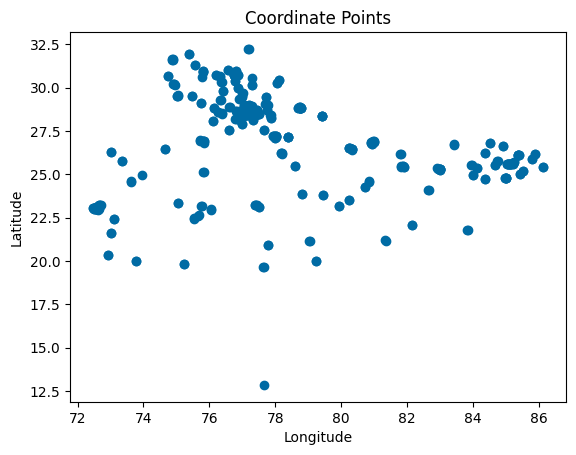

In [50]:
lats = [p[0] for p in plot_coords]
lons = [p[1] for p in plot_coords]

plt.figure()
plt.scatter(lons, lats)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Coordinate Points")
plt.show()

Conclusion: probably best to remove these for large scale data analysis, or on case by case basis

 - outside India Pak Nepal
 - Minimum number of entries
 - no changing lat/lon

In [63]:
# Step 1: find problematic coordinate pairs
bad_coords = (
    df.group_by(["lat", "lon"])
      .agg(pl.col("locationId").n_unique().alias("n_locationIds"))
      .filter(pl.col("n_locationIds") > 1)
      .select(["lat", "lon"])
)

# Step 2: keep only rows that belong to those coords
df_bad = df.join(bad_coords, on=["lat", "lon"], how="semi")

# Step 3: get min, max, and count(last_updated) per locationId
result = (
    df_bad.group_by(["lat", "lon", "locationId"])
          .agg([
              pl.len().alias("n_points"),
              pl.col("last_updated").min().alias("min_last_updated"),
              pl.col("last_updated").max().alias("max_last_updated"),
          ])
          .sort(["lat", "lon"])
)

for row in result.iter_rows():
    lat, lon, locationId, n_points, min_last_updated, max_last_updated = row
    print(
        f"({lat}, {lon}) - locationId: {locationId}\n"
        f"n_points: {n_points}\n"
        f"min: {min_last_updated}\n"
        f"max: {max_last_updated}\n\n"
    )

(13.0878, 80.2785) - locationId: 7023
n_points: 3
min: 2025-11-09 17:22:00
max: 2025-11-12 16:04:00


(13.0878, 80.2785) - locationId: 356DS1010002
n_points: 3
min: 2025-11-09 17:18:00
max: 2025-11-12 16:00:00


(13.1313, 80.1744) - locationId: PLLODA000661
n_points: 3
min: 2025-11-09 17:23:00
max: 2025-11-12 16:05:00


(13.1313, 80.1744) - locationId: PLLODA000659
n_points: 3
min: 2025-11-09 17:23:00
max: 2025-11-12 16:05:00


(17.3841, 78.4564) - locationId: 356DS1010005
n_points: 3
min: 2025-11-09 17:18:00
max: 2025-11-12 16:00:00


(17.3841, 78.4564) - locationId: 7022
n_points: 3
min: 2025-11-09 17:22:00
max: 2025-11-12 16:04:00


(19.0728, 72.8826) - locationId: 356DS1010004
n_points: 3
min: 2025-11-09 17:18:00
max: 2025-11-12 16:00:00


(19.0728, 72.8826) - locationId: 7020
n_points: 3
min: 2025-11-09 17:22:00
max: 2025-11-12 16:04:00


(24.4601, 74.883) - locationId: ACA7049F4E14
n_points: 1830
min: 2026-02-03 11:47:00
max: 2026-02-27 18:58:00


(24.4601, 74.883) - locationId: 

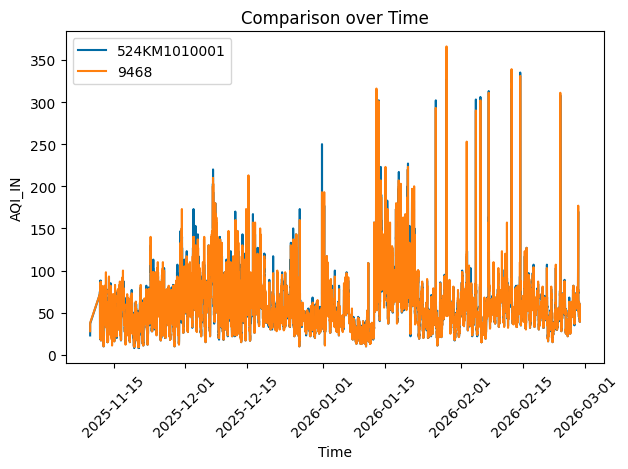

In [65]:
loc1 = "524KM1010001"
loc2 = "9468"
value_col = "AQI_IN"   # change this to whatever column you want

df_plot = (
    df.filter(pl.col("locationId").is_in([loc1, loc2]))
      .select(["locationId", "last_updated", value_col])
      .sort("last_updated")
)

# Convert to pandas for plotting
pdf = df_plot.to_pandas()

plt.figure()

for loc_id in [loc1, loc2]:
    subset = pdf[pdf["locationId"] == loc_id]
    plt.plot(subset["last_updated"], subset[value_col], label=loc_id)

plt.xlabel("Time")
plt.ylabel(value_col)
plt.title("Comparison over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bad boy nodes: 9469, 9468

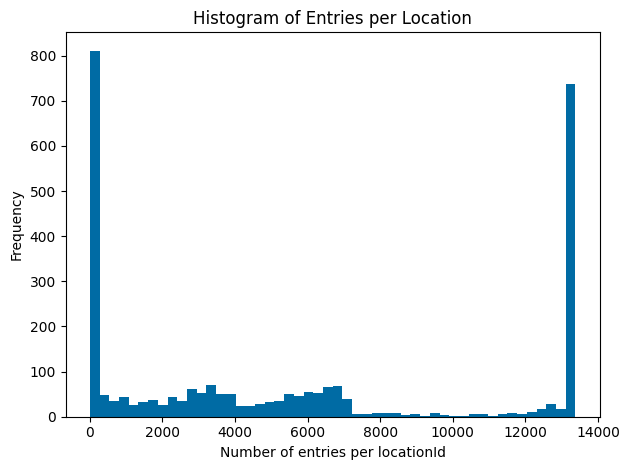

In [67]:
counts = (
    df.group_by("locationId")
      .len()
      .rename({"len": "n_entries"})
)

# Convert to pandas for plotting
pdf = counts.to_pandas()

plt.figure()
plt.hist(pdf["n_entries"], bins=50)
plt.xlabel("Number of entries per locationId")
plt.ylabel("Frequency")
plt.title("Histogram of Entries per Location")
plt.tight_layout()
plt.show()

In [73]:
(df.group_by("locationId").len().filter(pl.col("len") > 4500).height)

1383

LEARNINGS
 - cutoff ~4300-4500
 - India Pak Nepal only
 - ignore bad boy nodes which do location moving (like wtf)
 - ignore bad boy duplicate nodes